# GBM
#### 학습데이터에서 추정한 평균수익률(μ)과 변동성(σ)을 이용해 미래의 가격 경로를 확률적으로 생성
#### 평균수익률(μ)과 변동성(σ)을 바탕으로 여러 개의 가능한 미래 가격 경로와 그 분포를 탐색

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [13]:
'''
#시뮬레이션 함수 정의

s_0 : 시작주가
mu : 기대수익률
sigma : 변동성
n_sims : 시뮬레이션할 주가 경로 개수
T : 시뮬레이션 기간
N : 시간 구간 설정 개수
random_seed : 난수 재현을 위한 시드
antithetic_var : 대조변수법 사용여부
'''
def simulate_gbm(s_0, mu, sigma, n_sims, T, N, random_seed=42, antithetic_var=False):
    np.random.seed(random_seed)
    
    dt = T/N  #시간 간격 설정
    
    if antithetic_var:
        dW_ant = np.random.normal(scale = np.sqrt(dt), size=(int(n_sims/2), N)) #브라운 운동의 랜덤 변화량 생성
        dW = np.concatenate((dW_ant, -dW_ant), axis=0)                          #같은 난수의 반대 방향 생성
    else: 
        dW = np.random.normal(scale = np.sqrt(dt), size=(n_sims, N))
  
    # simulate the evolution of the proces
    S_t = s_0 * np.exp(np.cumsum((mu - 0.5 * sigma ** 2) * dt + sigma * dW, axis=1)) #GBM 공식
 
    return S_t

### 데이터 불러오기(마이크로소프트 2019년 1~7월)

In [4]:
FILE_PATH = "../Data-collection/dailyStock"
RISKY_ASSET = 'MSFT'
START_DATE = '2019-01-01'
END_DATE = '2019-07-31'

In [5]:
msft_df = pd.read_csv(f"{FILE_PATH}/{RISKY_ASSET}.csv", encoding="utf-8")
msft_df['Date'] = pd.to_datetime(msft_df['Date']) # 날짜로 변환
msft_df = msft_df.set_index('Date')               # Date를 인덱스로 설정
msft_df = msft_df.loc[START_DATE:END_DATE]        # 분석 기간

평균수익률: 0.22%


<Axes: title={'center': '마이크로소프트 단순수익률 2019-01-01~2019-07-31'}, xlabel='Date'>

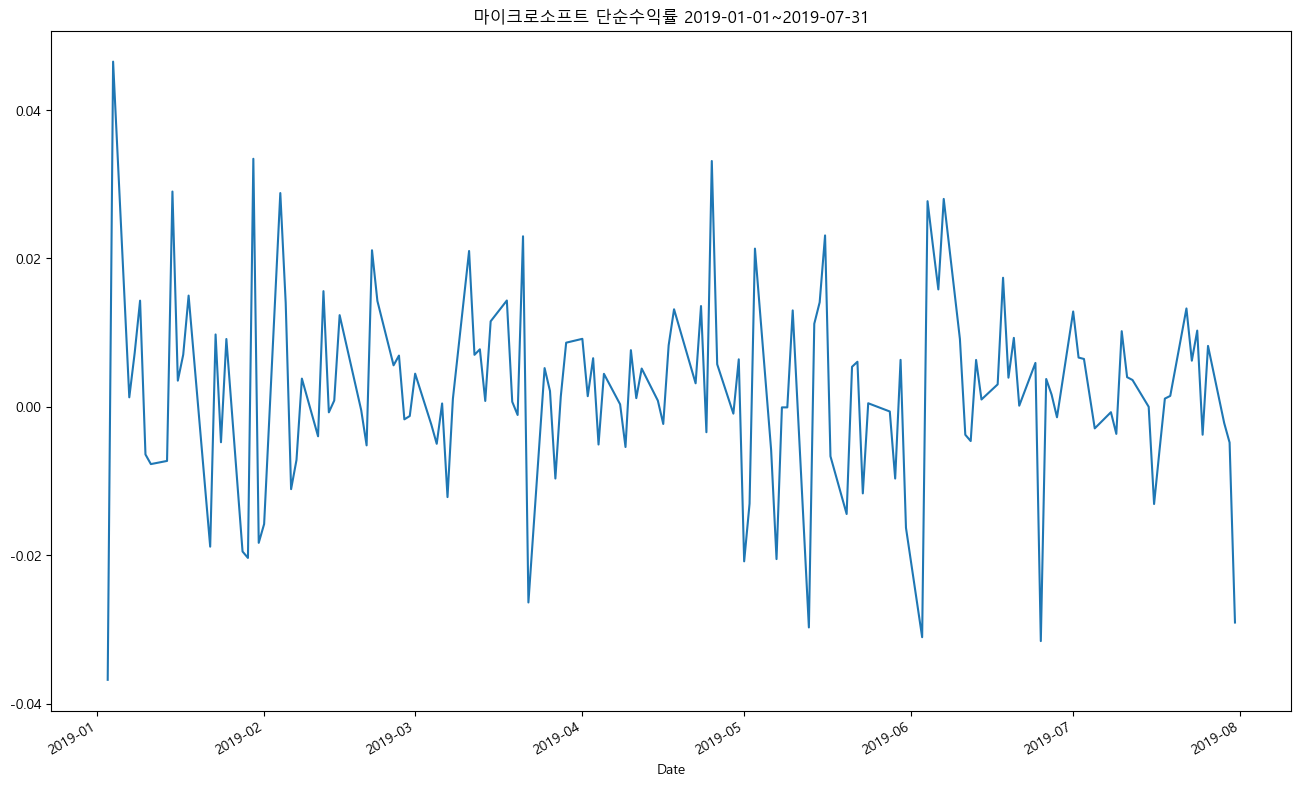

In [6]:
returns = msft_df["adj_close"].pct_change().dropna()
print(f'평균수익률: {100 * returns.mean():.2f}%')
returns.plot(title=f"마이크로소프트 단순수익률 {START_DATE}~{END_DATE}", figsize=(16,10))

### 훈련데이터와 테스트데이터 분할

In [7]:
train = returns['2019-01-01':'2019-06-30']
test = returns['2019-07-01':'2019-07-31']

### 시뮬레이션 매개변수 설정

In [15]:
T = len(test)  #1일간의 변동량 계산을 위해 T와 N을 동일한 크기로 설정
N = len(test)
S_0 = msft_df["adj_close"][train.index[-1]] #시작주가(훈련데이터의 마지막 일자)
N_SIM = 100    #시뮬레이션 갯수
mu = train.mean()
sigma = train.std()

In [17]:
gbm_simulations = simulate_gbm(S_0, mu, sigma, N_SIM, T, N, antithetic_var=True)
#시뮬레이션 결과를 df로 변환
gbm_simulations_df = pd.DataFrame(np.transpose(gbm_simulations), index=test.index)

### 시뮬레이션 결과 도식화

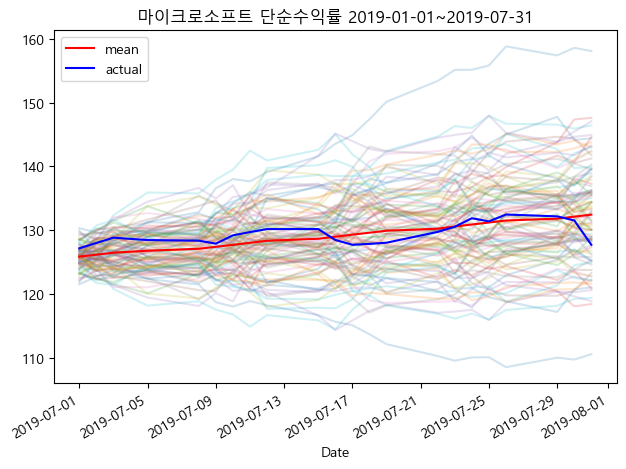

In [35]:
ax = gbm_simulations_df.plot(alpha=0.2, legend=False)
line_1, = ax.plot(index, gbm_simulations_df.mean(axis=1), color='red')
line_2, = ax.plot(index, msft_df["adj_close"][test.index[0]:test.index[-1]], color='blue')

ax.set_title(plot_title)
ax.legend((line_1, line_2), ('mean', 'actual'))

plt.tight_layout()
plt.show()